In [1]:
import joblib
from analysis_utils import *

# Görselleştirme Ayarları
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# --- 1. Upload Data ---
df = pd.read_csv("../datasets/drug200.csv")
print(f"1. Veri Yüklendi. Boyut: {df.shape}")

1. Veri Yüklendi. Boyut: (200, 6)


In [3]:
# --- 2. Genel Yapı, Tipler ve Eksik Veri Analizi ---
check_general_structure(df)

=== Veri Tipleri ve Non-Null Bilgisi ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 12.5 KB
None

=== Eksik Değer Özeti ===
Empty DataFrame
Columns: [Eksik Sayısı, Eksik Oranı (%)]
Index: []


,Eksik Sayısı,Eksik Oranı (%)
Age,0,0.0
Sex,0,0.0
BP,0,0.0
Cholesterol,0,0.0
Na_to_K,0,0.0
Drug,0,0.0


In [4]:
numeric_cols = df.select_dtypes(include=["number"])
categorical_cols = df.select_dtypes(
    include=["object", "category", "str"]
).columns.tolist()

--- Sayısal Sütun Dağılımları ---


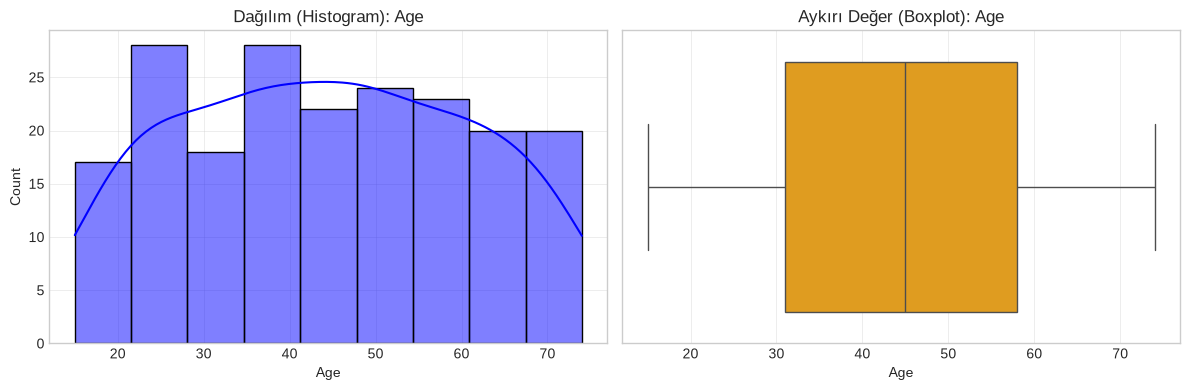

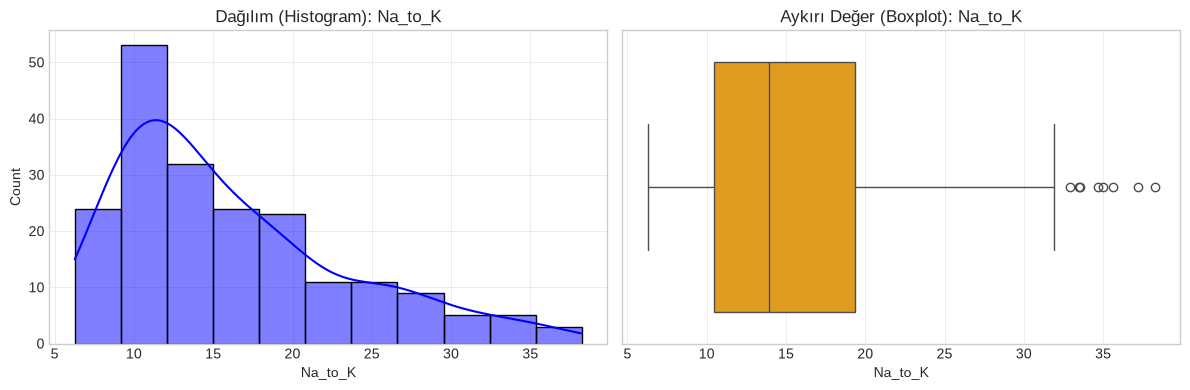

In [5]:
# Sayısal dağılımları çiz
print("--- Sayısal Sütun Dağılımları ---")
plot_statistical_distributions(df, numeric_cols)

--- Kategorik Sütun Dağılımları ---


/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:315: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:315: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:315: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:315: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

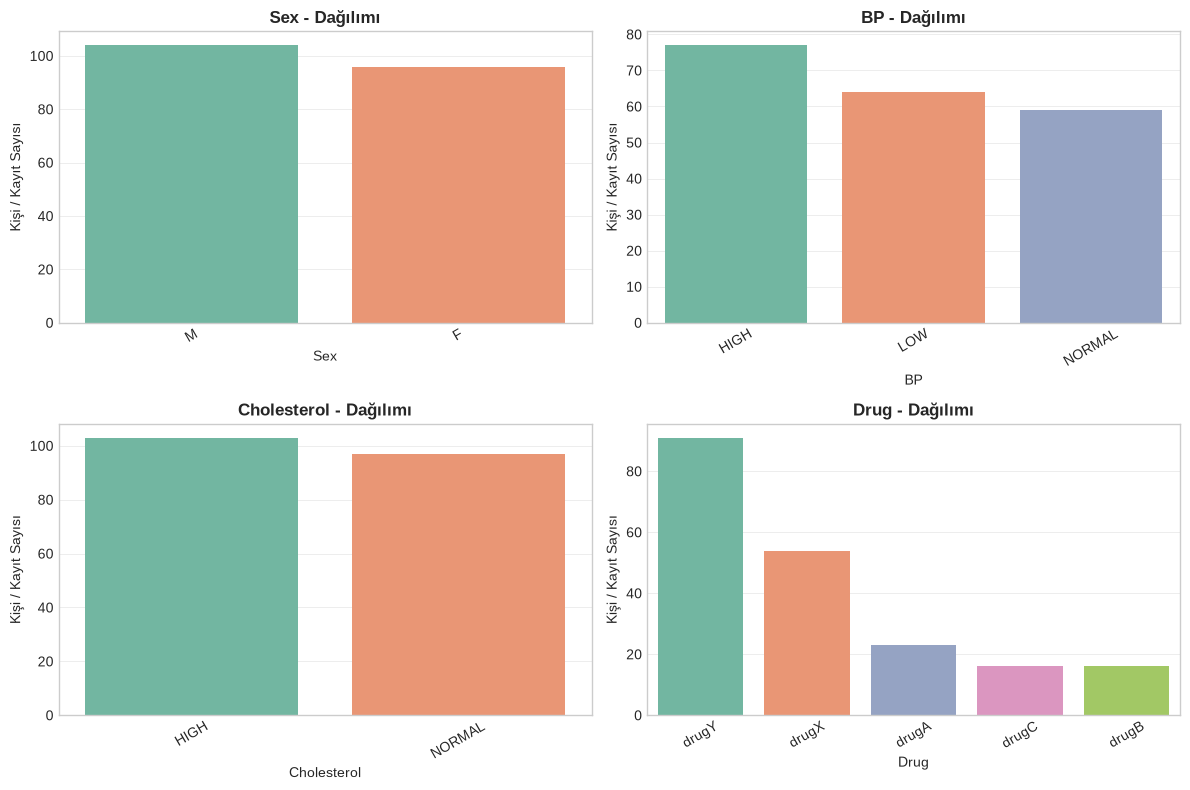

In [6]:
# Kategorik (String) dağılımları çiz
print("--- Kategorik Sütun Dağılımları ---")
plot_categorical_distributions(df, categorical_cols)

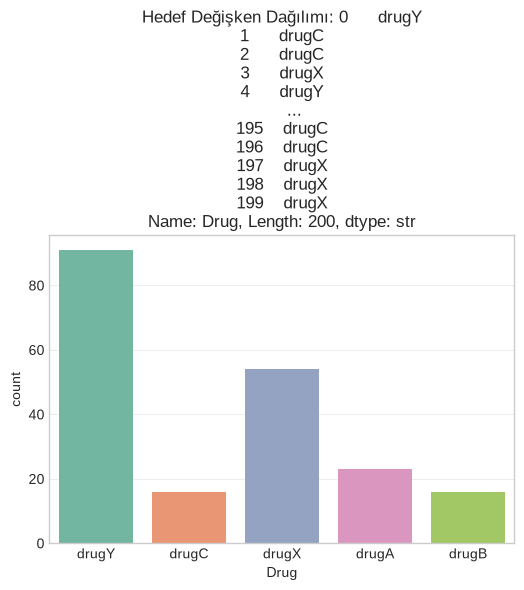

In [7]:
# --- 3. Hedef Değişken (Target) Dağılımı ---
target_column = df["Drug"]
plot_target_distribution(df, target_column)

Tespit edilen sayısal sütunlar: ['Age', 'Na_to_K']
Tespit edilen kategorik (string) sütunlar: ['Sex', 'BP', 'Cholesterol']
--- İstatistiksel Öznitelik Önem Analizi (Mutual Information) ---
              Feature  MI_Score
1             Na_to_K  0.707131
4           BP_NORMAL  0.244899
3              BP_LOW  0.169665
5  Cholesterol_NORMAL  0.098652
0                 Age  0.074204
2               Sex_M  0.000000


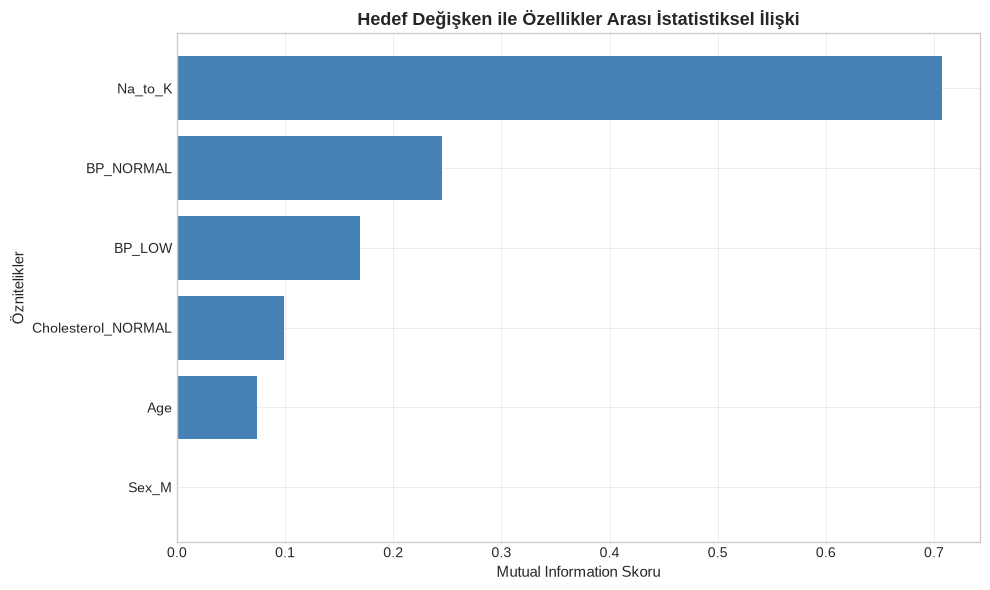

In [8]:
# --- 4. İstatistiksel İlişki Analizi (Mutual Information) ---
mi_results = calculate_and_plot_mutual_information(df, target_col="Drug")

In [9]:
target_corr, to_drop = analyze_mixed_feature_relations(df, target_col="Drug")

Tespit edilen sayısal sütunlar: ['Age', 'Na_to_K']
Tespit edilen kategorik (string) sütunlar: ['Sex', 'BP', 'Cholesterol']
--- Karma/Kategorik Özellik İlişki Skorları (Mutual Information) ---
Na_to_K               0.707131
BP_NORMAL             0.244899
BP_LOW                0.169665
Cholesterol_NORMAL    0.098652
Age                   0.074204
Sex_M                 0.000000
dtype: float64
Düşürülebilecek Düşük Skorlu Sütunlar: ['Sex_M']


In [10]:
# --- 5. Verinin Eğitim ve Test Olarak Ayrılması ---
X = df.drop(columns=["Drug"])
y = df["Drug"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n5. Veri Bölündü -> Train: {X_train.shape}, Test: {X_test.shape}")


5. Veri Bölündü -> Train: (160, 5), Test: (40, 5)


In [11]:
# --- 6. Outlier Değerleri Belirleme ---
numerical_cols = df.drop(columns=["Sex","BP","Cholesterol","Drug"])
X_train_clipped, X_test_clipped, outlier_summary = apply_iqr_clipping(X_train, X_test, numerical_cols)

=== Aykırı Değer (Outlier) Sayıları ===
🔸 Na_to_K: 5 adet aykırı değer bulundu.
8. IQR Clipping İşlemi Tamamlandı (Faktör: 1.5).


In [12]:
# --- 7. Correlation Filtresi (Clipping Sonrasında) ---
X_train_corr, X_test_corr = correlation_filter(
    X_train_clipped, X_test_clipped, corr_threshold=0.95
)

9. Korelasyon Filtresi Sonrası Kalan Özellik Sayısı: 5


In [13]:
# --- Sabit (Constant) Sütunları Temizleme ---
constant_cols = [col for col in X_train_corr.columns if X_train_corr[col].nunique() <= 1]

if constant_cols:
    print(f"Sabit sütunlar tespit edildi ve çıkarılıyor: {constant_cols}")
    X_train_corr = X_train_corr.drop(columns=constant_cols)
    X_test_corr = X_test_corr.drop(columns=constant_cols)
else:
    print("Sabit sütun bulunamadı.")

Sabit sütun bulunamadı.


In [14]:
# --- 8. Öznitelik Seçimi (Feature Selection) ---
selected_features = select_best_features_anova_string(X_train_corr, y_train)

# Liste içindeki None veya NaN değerleri temizleyelim
selected_features = [
    f for f in selected_features if f is not None and pd.notna(f)
]

X_train_selected = X_train_corr[selected_features]
X_test_selected = X_test_corr[selected_features]

=== En İyi 5 Özellik (ANOVA) ===
              Feature      Score
1             Na_to_K  80.129361
4           BP_NORMAL  18.213579
3              BP_LOW  14.030061
0                 Age   6.126107
5  Cholesterol_NORMAL   4.250151


KeyError: "['BP_NORMAL', 'BP_LOW', 'Cholesterol_NORMAL'] not in index"

In [ ]:
# Hepsini tek bir pakette topla
bundle = {
    "X_train": X_train_selected,
    "X_test": X_test_selected,
    "y_train": y_train,
    "y_test": y_test,
}
# Tek dosyaya kaydet
joblib.dump(bundle, "../backend/models/drug/drug_data_bundle.pkl")
print(
    "İşlenmiş drug veri setleri başarıyla backend/models/drug/"
    " klasörüne kaydedildi!"
)